In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df_bank = pd.read_csv("C:/Users/laazz/Documents/The Power/Trabajos/The_Power/bank-additional.csv")
xls = pd.ExcelFile("C:/Users/laazz/Documents/The Power/Trabajos/The_Power/customer-details.xlsx")

df_customers = pd.concat([
    pd.read_excel(xls, sheet_name=0),
    pd.read_excel(xls, sheet_name=1),
    pd.read_excel(xls, sheet_name=2)
], ignore_index=True)

In [5]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df_bank = pd.read_csv("C:/Users/laazz/Documents/The Power/Trabajos/The_Power/bank-additional.csv")
xls = pd.ExcelFile("C:/Users/laazz/Documents/The Power/Trabajos/The_Power/customer-details.xlsx")

df_customers = pd.concat([
    pd.read_excel(xls, sheet_name=0),
    pd.read_excel(xls, sheet_name=1),
    pd.read_excel(xls, sheet_name=2)
], ignore_index=True)

In [4]:
# Duplicados
df_bank.drop_duplicates(inplace=True)
df_customers.drop_duplicates(inplace=True)

# Fechas
df_bank['date'] = pd.to_datetime(df_bank['date'], errors='coerce')
df_customers['Dt_Customer'] = pd.to_datetime(df_customers['Dt_Customer'], errors='coerce')

# Variables binarias
df_bank['y'] = df_bank['y'].map({'yes': 1, 'no': 0})

# Ver nulos
print(df_bank.isnull().sum())
print(df_customers.isnull().sum())

C:\Users\laazz\AppData\Local\Temp\ipykernel_39428\3250555482.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_bank['date'] = pd.to_datetime(df_bank['date'], errors='coerce')


Unnamed: 0            0
age                5120
job                 345
marital              85
education          1807
default            8981
housing            1026
loan               1026
contact               0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
emp.var.rate          0
cons.price.idx      471
cons.conf.idx         0
euribor3m          9256
nr.employed           0
y                     0
date              43000
latitude              0
longitude             0
id_                   0
dtype: int64
Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64


In [13]:
df = df_bank.merge(df_customers, left_on='id_', right_on='ID', how='left')

In [ ]:
df['y'].value_counts(normalize=True)
# Solo un pequeño porcentaje contrata #

y
0    0.887349
1    0.112651
Name: proportion, dtype: float64

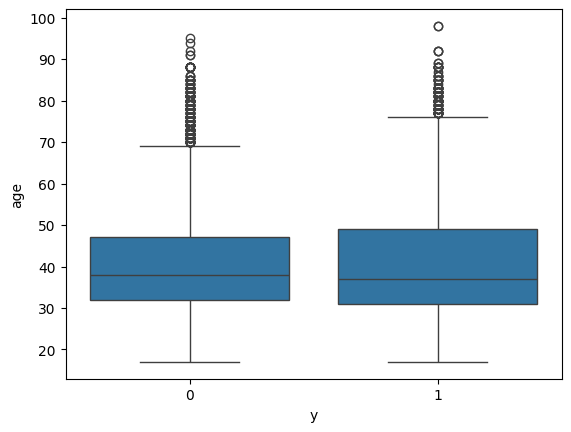

In [ ]:
sns.boxplot(x='y', y='age', data=df)
plt.show()
#Los clientes que contratan suelen tener una edad ligeramente mayor#

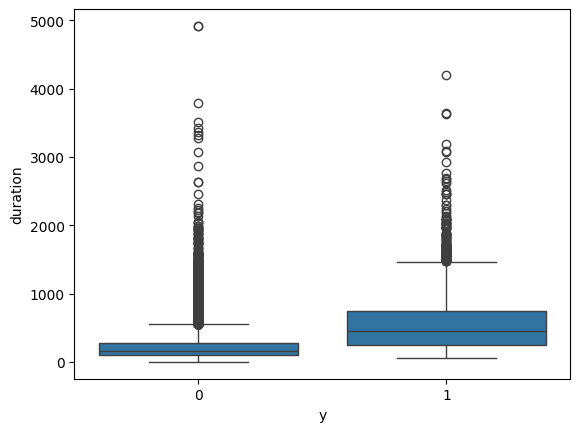

In [ ]:
sns.boxplot(x='y', y='duration', data=df)
plt.show()
#Cuanto mas duran las llamadas mas probabilidades de contratación#

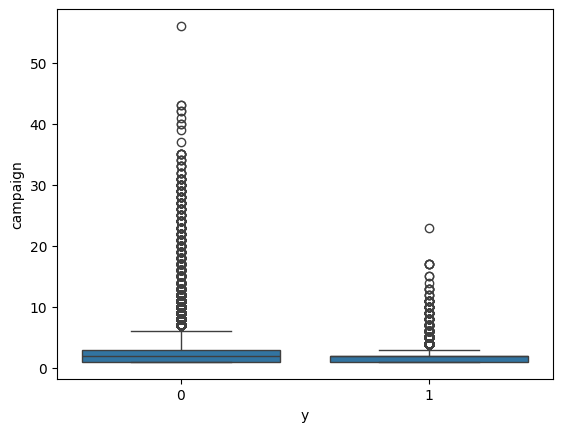

In [ ]:
sns.boxplot(x='y', y='campaign', data=df)
plt.show()
# Cuanto mas contactos menos probabilidad de cotratar#

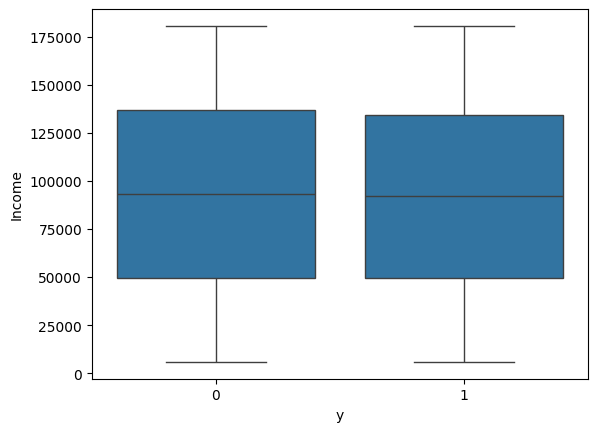

In [ ]:
sns.boxplot(x='y', y='Income', data=df)
plt.show()
#No se ve diferencia#

In [ ]:
df.groupby('job')['y'].mean().sort_values(ascending=False)
#alguno trabajos pueden tener mas conversión#

job
student          0.313400
retired          0.251955
unemployed       0.143932
admin.           0.130139
management       0.112131
technician       0.108454
self-employed    0.108126
housemaid        0.098842
entrepreneur     0.082786
services         0.080730
blue-collar      0.068883
Name: y, dtype: float64

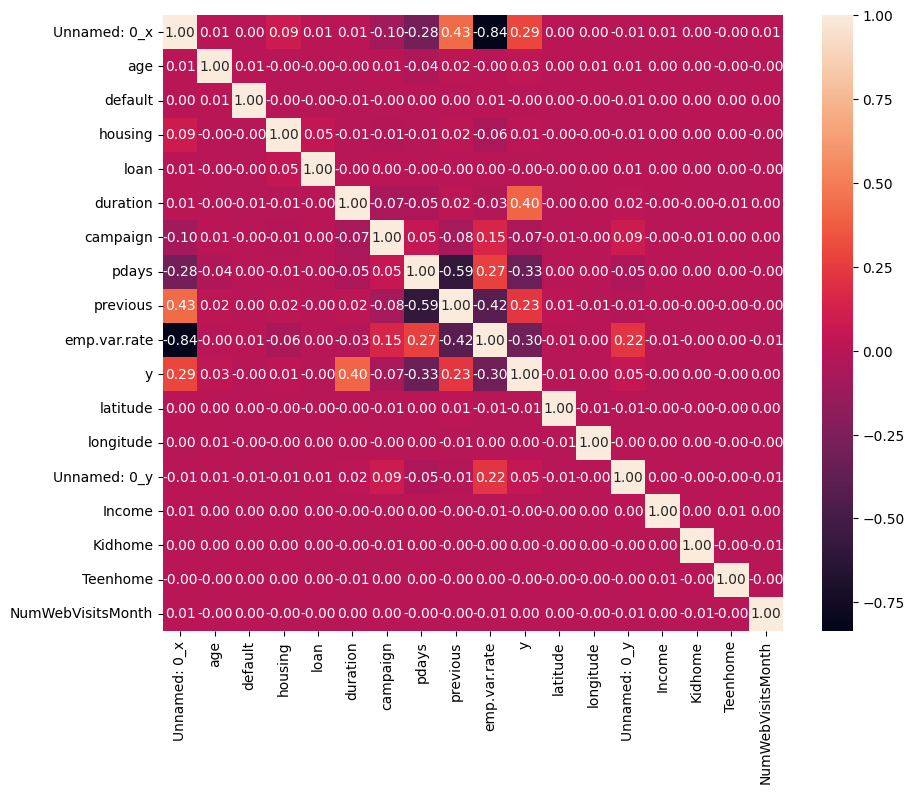

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.show()

In [23]:
# Crear variable nueva
df['total_children'] = df['Kidhome'] + df['Teenhome']

# Segmentación
df.groupby('total_children')['y'].mean()

total_children
0    0.117375
1    0.107955
2    0.115250
3    0.110168
4    0.114526
Name: y, dtype: float64